In [ ]:
# Importación de Librerías Esenciales

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display # Importamos la herramienta de renderizado

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

<div class="alert alert-block alert-info">
    <h1>Taller Práctico: Regresión Lineal, Ridge y Lasso</h1>
    <p><strong>Objetivos de la sesión:</strong></p>
    <ul>
        <li>Aplicar los conceptos de regresión lineal en un problema práctico.</li>
        <li>Implementar y comparar modelos de Regresión Lineal, Ridge y Lasso.</li>
        <li>Utilizar la validación cruzada para encontrar el hiperparámetro de regularización óptimo.</li>
        <li>Evaluar el rendimiento de los modelos utilizando métricas como MSE, MAE y R².</li>
    </ul>
    <p><strong>Dataset:</strong> Utilizaremos el dataset "Ames Housing", que contiene información sobre la venta de casas en Ames, Iowa. Nuestro objetivo será predecir el precio de venta (<code>SalePrice</code>) de las casas.</p>
</div>

### 1. Carga y Exploración de Datos (EDA)

<p>El primer paso en cualquier proyecto de Machine Learning es entender nuestros datos. Cargaremos el dataset, veremos su estructura y realizaremos algunas visualizaciones iniciales.</p>

In [ ]:
# Cargar el dataset Ames Housing desde OpenML
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame
# Configuramos para ver las 81 columnas
pd.set_option('display.max_columns', None)

print(f"\nDimensiones del conjunto de datos: {df.shape}")
# EN LUGAR DE PRINT, USAMOS DISPLAY:
display(df.head())
print("\nDescripción estadística del conjunto:")
print(df.describe())

# Seleccionamos un subconjunto de características numéricas para simplificar el taller
# y la variable objetivo 'SalePrice'
numeric_features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'FullBath', 'GarageCars']
target_variable = 'SalePrice'

# Creamos un DataFrame más pequeño y manejamos valores faltantes de forma simple
df_subset = df[numeric_features + [target_variable]].dropna()

print(f"\nDimensiones del subconjunto de datos: {df_subset.shape}")
print("\nDescripción estadística del subconjunto:")
print(df_subset.describe())


Dimensiones del conjunto de datos: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Descripción estadística del conjunto:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726   
std       1.112799    30.202904     20.645407   181

<p>Ahora, visualicemos la distribución de nuestra variable objetivo y la relación entre el área de la vivienda y su precio. La distribución de precios está sesgada, por lo que una transformación logarítmica será útil.</p>

In [ ]:
# Histograma del Precio de Venta (SalePrice)
fig_hist = px.histogram(df_subset, x='SalePrice', nbins=50, title='Distribución del Precio de Venta de las Casas (Original)')
fig_hist.update_layout(xaxis_title='Precio de Venta (USD)', yaxis_title='Cantidad de casas')
fig_hist.show()

# Histograma del log(Precio de Venta)
fig_hist_log = px.histogram(x=np.log1p(df_subset['SalePrice']), nbins=50, title='Distribución del log(Precio de Venta)')
fig_hist_log.update_layout(xaxis_title='log(1 + Precio de Venta)', yaxis_title='Cantidad de casas')
fig_hist_log.show()

### 2. Preparación de Datos

<p>Ahora aplicaremos los cambios necesarios: división de datos, transformación logarítmica del objetivo y escalado de características.</p>

In [ ]:
# 1. Definir características (X) y objetivo (y)
X = df_subset[numeric_features]
y_raw = df_subset[target_variable] # Guardamos el 'y' original para evaluación final

# !! CAMBIO CLAVE !!
# Aplicamos la transformación logarítmica a la variable objetivo 'y'
# Esto estabiliza la varianza y normaliza la escala del problema.
y = np.log1p(y_raw)

# 2. Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

# 3. Escalar las características numéricas
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar fuga de datos (data leakage)
X_train_scaled = scaler.fit_transform(X_train)  #NORMALIZA, RESTA LA MEDIA Y DIVIDE POR LA DISPERSION
# Aplicamos la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

# Convertimos los arrays de numpy de vuelta a DataFrames de pandas para mejor legibilidad
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_features)

Tamaño del set de entrenamiento: (1168, 6)
Tamaño del set de prueba: (292, 6)


### 3. Regresión Lineal (Mínimos Cuadrados Ordinarios)

<p>Entrenamos nuestro modelo base con los datos transformados. El MSE será un número pequeño y manejable.</p>

In [ ]:
# Crear y entrenar el modelo de Regresión Lineal
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba (las predicciones estarán en escala logarítmica)
y_pred_ols = ols_model.predict(X_test_scaled)

# Evaluar el modelo
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("--- Evaluación del Modelo de Regresión Lineal (OLS) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_ols:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_ols:.4f}")

# Ver los coeficientes del modelo
coef_df = pd.DataFrame(ols_model.coef_, index=numeric_features, columns=['Coeficiente_OLS'])
print("\nCoeficientes del modelo OLS:")
print(coef_df)
print(f"Ordenada al origen (Intercept): {ols_model.intercept_}")
print(f"Precio base promedio en USD: {np.expm1(ols_model.intercept_)}")

--- Evaluación del Modelo de Regresión Lineal (OLS) ---
Error Cuadrático Medio (MSE en escala log): 0.0303
Coeficiente de Determinación (R²): 0.8375

Coeficientes del modelo OLS:
             Coeficiente_OLS
GrLivArea           0.126585
OverallQual         0.138404
YearBuilt           0.074407
TotalBsmtSF         0.044540
FullBath           -0.006889
GarageCars          0.071504
Ordenada al origen (Intercept): 12.030658310971573
Precio base promedio en USD: 167820.85535223948


#Así queda la fórmula
$$\log(1 + \text{SalePrice}) = 12.0307 + 0.1266(GrLivArea) + 0.1384(OverallQual) + 0.0744(YearBuilt) + 0.0445(TotalBsmtSF) - 0.0069(FullBath) + 0.0715(GarageCars)$$

### 4. Regresión con Regularización: Ridge (L2) y Lasso (L1)

<p>Con el objetivo ya transformado, ahora `alpha` tendrá el efecto esperado. Usaremos un valor pequeño para ver el contraste.</p>

In [ ]:
# --- Ridge Regression (L2) ---
ridge_model = Ridge(alpha=100.) # Alpha grande
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("--- Evaluación del Modelo Ridge (alpha=100.) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_ridge:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_ridge:.4f}")

# --- Lasso Regression (L1) ---
lasso_model = Lasso(alpha=0.1) # Alpha pequeño
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Evaluación del Modelo Lasso (alpha=0.1) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_lasso:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_lasso:.4f}")

# Comparar coeficientes
coef_df['Coef_Ridge_alpha100'] = ridge_model.coef_
coef_df['Coef_Lasso_alpha0.1'] = lasso_model.coef_
print("\n--- Comparación de Coeficientes ---")
print(coef_df.round(4))

--- Evaluación del Modelo Ridge (alpha=100.) ---
Error Cuadrático Medio (MSE en escala log): 0.0310
Coeficiente de Determinación (R²): 0.8340

--- Evaluación del Modelo Lasso (alpha=0.1) ---
Error Cuadrático Medio (MSE en escala log): 0.0579
Coeficiente de Determinación (R²): 0.6895

--- Comparación de Coeficientes ---
             Coeficiente_OLS  Coef_Ridge_alpha100  Coef_Lasso_alpha0.1
GrLivArea             0.1266               0.1120               0.0567
OverallQual           0.1384               0.1285               0.1479
YearBuilt             0.0744               0.0673               0.0050
TotalBsmtSF           0.0445               0.0499               0.0060
FullBath             -0.0069               0.0080               0.0000
GarageCars            0.0715               0.0723               0.0486


<p> Fijate cómo los coeficientes de Ridge son sistemáticamente penalizados (encogidos) respecto de los de OLS. Y más importante, mirá los coeficientes de Lasso: con un `alpha` de solo 0.1, redujo el coeficiente de `FullBath` casi a cero, demostrando su poder de selección de características.</p>

### 5. Selección de Hiperparámetros con Validación Cruzada

<p>Finalmente, usamos `RidgeCV` y `LassoCV` para encontrar el `alpha` óptimo de manera automática.cv VIENE DE CROSS VALIDATION</p>

In [ ]:
# Definir un rango de alphas para probar
alphas = np.logspace(-4, 2, 100)

#print(f"El contenido de alphas es:{alphas}")

# --- RidgeCV ---
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv.fit(X_train_scaled, y_train)

print("--- Búsqueda del mejor Alpha para Ridge ---")
print(f"Mejor alpha encontrado para Ridge: {ridge_cv.alpha_:.4f}")

# Evaluar el modelo Ridge final con el mejor alpha
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
print(f"MSE de Ridge con CV: {mse_ridge_cv:.4f}")
print(f"R² de Ridge con CV: {r2_ridge_cv:.4f}")

# --- LassoCV ---
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("\n--- Búsqueda del mejor Alpha para Lasso ---")
print(f"Mejor alpha encontrado para Lasso: {lasso_cv.alpha_:.4f}")

# Evaluar el modelo Lasso final
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
print(f"MSE de Lasso con CV: {mse_lasso_cv:.4f}")
print(f"R² de Lasso con CV: {r2_lasso_cv:.4f}")

# Añadir los coeficientes finales al DataFrame
coef_df['Coef_Ridge_CV'] = ridge_cv.coef_
coef_df['Coef_Lasso_CV'] = lasso_cv.coef_
print("\n--- Comparación Final de Coeficientes ---")
print(coef_df.round(4))

#Revertimos las predicciones logarítmicas a dólares reales
y_pred_usd = np.expm1(y_pred_lasso_cv)

#Revertimos el objetivo real de PRUEBA a dólares reales (292 datos)
y_test_usd = np.expm1(y_test)

#Calculamos el Error Absoluto Medio (MAE) en la escala original
mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)

print("--- Evaluación en Escala Real (Dólares) ---")
print(f"Error Absoluto Medio (MAE): {mae_usd:,.2f} USD")

--- Búsqueda del mejor Alpha para Ridge ---
Mejor alpha encontrado para Ridge: 86.9749
MSE de Ridge con CV: 0.0309
R² de Ridge con CV: 0.8346

--- Búsqueda del mejor Alpha para Lasso ---
Mejor alpha encontrado para Lasso: 0.0043
MSE de Lasso con CV: 0.0307
R² de Lasso con CV: 0.8357

--- Comparación Final de Coeficientes ---
             Coeficiente_OLS  Coef_Ridge_alpha100  Coef_Lasso_alpha0.1  \
GrLivArea             0.1266               0.1120               0.0567   
OverallQual           0.1384               0.1285               0.1479   
YearBuilt             0.0744               0.0673               0.0050   
TotalBsmtSF           0.0445               0.0499               0.0060   
FullBath             -0.0069               0.0080               0.0000   
GarageCars            0.0715               0.0723               0.0486   

             Coef_Ridge_CV  Coef_Lasso_CV  
GrLivArea           0.1135         0.1199  
OverallQual         0.1297         0.1385  
YearBuilt           0.

### 6. Desafíos para Experimentar

<p>Ahora es tu turno de experimentar. Respondé a las siguientes preguntas modificando el código anterior:</p>
<ol>
    <li><strong>Añadir más características:</strong> Elegí otras 2 o 3 features numéricos del `df` original, añadilos a la lista `numeric_features` y volvé a ejecutar todo el notebook. ¿Mejora el R² del modelo final?</li>
    <li><strong>Interpretación de coeficientes:</strong> Observá los coeficientes finales del modelo `LassoCV`. ¿Qué característica parece ser la más importante según este modelo? ¿Cuáles ha descartado (coeficiente cercano a cero)?</li>
    <li><strong>Evaluación en escala original:</strong> Las predicciones (`y_pred_lasso_cv`) están en escala logarítmica. Usá `np.expm1()` para convertirlas de nuevo a dólares. Luego, calculá el Error Absoluto Medio (MAE) entre las predicciones revertidas y el `y_test` original (que deberías haber guardado como `y_raw`). ¿Cuál es el error promedio en dólares de tu mejor modelo?</li>
</ol>

#Respuestas:
1.   Si, mejora el R2, no por mucho porque ya era bueno, pero lo mejora.
2.   La característica más importante del modelo Lasso es Overall Quality, la misma muestra un valor de 0.1261 (el mayor de todos los valores). Las que ha descartado son las de FullBath y BedroomAbvGr.
3. Error Absoluto Medio (MAE): 20,953.48 USD


In [ ]:
print(f"\nDimensiones del conjunto de datos: {df.shape}")
# EN LUGAR DE PRINT, USAMOS DISPLAY:
#display(df.head())
#print("\nDescripción estadística del conjunto:")
#print(df.describe())

# Seleccionamos un subconjunto de características numéricas para simplificar el taller
# y la variable objetivo 'SalePrice'
numeric_features_plus = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'FullBath', 'GarageCars','LotArea', 'OverallCond','BedroomAbvGr']
target_variable = 'SalePrice'

# Creamos un DataFrame más pequeño y manejamos valores faltantes de forma simple
df_subset_plus = df[numeric_features_plus + [target_variable]].dropna().select_dtypes(include='number')

print(f"\nDimensiones del subconjunto de datos: {df_subset_plus.shape}")
print("\nDescripción estadística del subconjunto:")
display(df_subset_plus.head())
print(df_subset_plus.describe())


Dimensiones del conjunto de datos: (1460, 81)

Dimensiones del subconjunto de datos: (1460, 10)

Descripción estadística del subconjunto:


,GrLivArea,OverallQual,YearBuilt,TotalBsmtSF,FullBath,GarageCars,LotArea,OverallCond,BedroomAbvGr,SalePrice
0,1710,7,2003,856,2,2,8450,5,3,208500
1,1262,6,1976,1262,2,2,9600,8,3,181500
2,1786,7,2001,920,2,2,11250,5,3,223500
3,1717,7,1915,756,1,3,9550,5,3,140000
4,2198,8,2000,1145,2,3,14260,5,4,250000


         GrLivArea  OverallQual    YearBuilt  TotalBsmtSF     FullBath  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean   1515.463699     6.099315  1971.267808  1057.429452     1.565068   
std     525.480383     1.382997    30.202904   438.705324     0.550916   
min     334.000000     1.000000  1872.000000     0.000000     0.000000   
25%    1129.500000     5.000000  1954.000000   795.750000     1.000000   
50%    1464.000000     6.000000  1973.000000   991.500000     2.000000   
75%    1776.750000     7.000000  2000.000000  1298.250000     2.000000   
max    5642.000000    10.000000  2010.000000  6110.000000     3.000000   

        GarageCars        LotArea  OverallCond  BedroomAbvGr      SalePrice  
count  1460.000000    1460.000000  1460.000000   1460.000000    1460.000000  
mean      1.767123   10516.828082     5.575342      2.866438  180921.195890  
std       0.747315    9981.264932     1.112799      0.815778   79442.502883  
min       0.000000   

In [ ]:
# 1. Definir características (X) y objetivo (y)
X = df_subset_plus[numeric_features_plus]
y_raw = df_subset[target_variable] # Guardamos el 'y' original para evaluación final

# !! CAMBIO CLAVE !!
# Aplicamos la transformación logarítmica a la variable objetivo 'y'
# Esto estabiliza la varianza y normaliza la escala del problema.
y = np.log1p(y_raw)

# 2. Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

# 3. Escalar las características numéricas
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar fuga de datos (data leakage)
X_train_scaled = scaler.fit_transform(X_train)  #NORMALIZA, RESTA LA MEDIA Y DIVIDE POR LA DISPERSION
# Aplicamos la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

# Convertimos los arrays de numpy de vuelta a DataFrames de pandas para mejor legibilidad
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features_plus)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_features_plus)

Tamaño del set de entrenamiento: (1168, 9)
Tamaño del set de prueba: (292, 9)


In [ ]:
# Crear y entrenar el modelo de Regresión Lineal
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba (las predicciones estarán en escala logarítmica)
y_pred_ols = ols_model.predict(X_test_scaled)

# Evaluar el modelo
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("--- Evaluación del Modelo de Regresión Lineal (OLS) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_ols:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_ols:.4f}")

# Ver los coeficientes del modelo
coef_df = pd.DataFrame(ols_model.coef_, index=numeric_features_plus, columns=['Coeficiente_OLS'])
print("\nCoeficientes del modelo OLS:")
print(coef_df)
print(f"Ordenada al origen (Intercept): {ols_model.intercept_}")
print(f"Precio base promedio en USD: {np.expm1(ols_model.intercept_)}")

--- Evaluación del Modelo de Regresión Lineal (OLS) ---
Error Cuadrático Medio (MSE en escala log): 0.0246
Coeficiente de Determinación (R²): 0.8680

Coeficientes del modelo OLS:
              Coeficiente_OLS
GrLivArea            0.124393
OverallQual          0.123754
YearBuilt            0.108563
TotalBsmtSF          0.042973
FullBath            -0.003818
GarageCars           0.068857
LotArea              0.031874
OverallCond          0.065631
BedroomAbvGr         0.001039
Ordenada al origen (Intercept): 12.030658310971573
Precio base promedio en USD: 167820.85535223948


In [ ]:
# Definir un rango de alphas para probar
alphas = np.logspace(-4, 2, 100)

#print(f"El contenido de alphas es:{alphas}")

# --- RidgeCV ---
ridge_cv = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv.fit(X_train_scaled, y_train)

print("--- Evaluación del Modelo de Regresión Lineal (OLS) ---")
print(f"Error Cuadrático Medio (MSE en escala log): {mse_ols:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_ols:.4f}")

print("\n--- Búsqueda del mejor Alpha para Ridge ---")
print(f"Mejor alpha encontrado para Ridge: {ridge_cv.alpha_:.4f}")

# Evaluar el modelo Ridge final con el mejor alpha
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
print(f"MSE de Ridge con CV: {mse_ridge_cv:.4f}")
print(f"R² de Ridge con CV: {r2_ridge_cv:.4f}")

# --- LassoCV ---
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("\n--- Búsqueda del mejor Alpha para Lasso ---")
print(f"Mejor alpha encontrado para Lasso: {lasso_cv.alpha_:.4f}")

# Evaluar el modelo Lasso final
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)
print(f"MSE de Lasso con CV: {mse_lasso_cv:.4f}")
print(f"R² de Lasso con CV: {r2_lasso_cv:.4f}")

# Añadir los coeficientes finales al DataFrame
coef_df['Coef_Ridge_CV'] = ridge_cv.coef_
coef_df['Coef_Lasso_CV'] = lasso_cv.coef_
print("\n--- Comparación Final de Coeficientes ---")
print(coef_df.round(4))

--- Evaluación del Modelo de Regresión Lineal (OLS) ---
Error Cuadrático Medio (MSE en escala log): 0.0246
Coeficiente de Determinación (R²): 0.8680

--- Búsqueda del mejor Alpha para Ridge ---
Mejor alpha encontrado para Ridge: 86.9749
MSE de Ridge con CV: 0.0254
R² de Ridge con CV: 0.8638

--- Búsqueda del mejor Alpha para Lasso ---
Mejor alpha encontrado para Lasso: 0.0057
MSE de Lasso con CV: 0.0255
R² de Lasso con CV: 0.8631

--- Comparación Final de Coeficientes ---
              Coeficiente_OLS  Coef_Ridge_CV  Coef_Lasso_CV
GrLivArea              0.1244         0.1077         0.1191
OverallQual            0.1238         0.1207         0.1261
YearBuilt              0.1086         0.0944         0.0982
TotalBsmtSF            0.0430         0.0479         0.0413
FullBath              -0.0038         0.0093         0.0000
GarageCars             0.0689         0.0708         0.0676
LotArea                0.0319         0.0311         0.0278
OverallCond            0.0656         0.058

### 7. Ejercicios Propuestos

<div class="alert alert-block alert-warning">
<h4>Ejercicios para Solidificar Conceptos</h4>
<ol>
    <li><strong>Evaluación de Residuos:</strong> Para el mejor modelo que encontraste (probablemente RidgeCV o LassoCV), calculá los residuos ($y_{test} - \hat{y}$) y creá un gráfico de dispersión de los valores predichos vs. los residuos. ¿Observás algún patrón? Un patrón podría indicar que la relación no es puramente lineal.</li>
    <li><strong>Cambiar la Métrica de CV:</strong> En `LassoCV` y `RidgeCV`, el scoring por defecto es el error cuadrático negativo. Investigá cómo podrías usar el "mean_absolute_error" en su lugar. ¿Cambia el `alpha` seleccionado?</li>
    <li><strong>Implementar K-Fold a Mano:</strong> En lugar de usar `RidgeCV`, instancia un `KFold(n_splits=5)`, iterá sobre los pliegues, entrená un modelo `Ridge` para un alpha fijo en cada pliegue y calculá el error promedio. Compará tu resultado con el de la clase `RidgeCV`.</li>
    <li><strong>Características Polinómicas:</strong> Sospechamos que la relación entre `GrLivArea` y `SalePrice` no es perfectamente lineal. Usá `sklearn.preprocessing.PolynomialFeatures` para crear una característica `GrLivArea` al cuadrado y añadila al modelo. ¿Mejora el R²?</li>
    <li><strong>Impacto de Outliers:</strong> Encontrá la casa más cara en el `df_subset`. Eliminala y volvé a entrenar el modelo OLS (con el target logarítmico). ¿Cómo cambian los coeficientes y el R²?</li>
    <li><strong>Comparar MAE vs MSE:</strong> Calculá el `mean_absolute_error` (MAE) para todos los modelos finales (OLS, RidgeCV, LassoCV) en la escala logarítmica. ¿Por qué el MAE es menor que el MSE?</li>
    <li><strong>Importancia de Características:</strong> Ordená los coeficientes del modelo `RidgeCV` final de mayor a menor en valor absoluto. ¿Cuáles son los 3 features más influyentes según este modelo?</li>
    <li><strong>Efecto del Alpha en Lasso:</strong> Creá un gráfico que muestre cómo cambian los coeficientes de Lasso a medida que `alpha` aumenta. Podés usar la información almacenada en `lasso_cv.path_`.</li>
    <li><strong>Regresión Lineal Simple vs. Múltiple:</strong> Entrená un modelo de regresión lineal simple para cada una de las características en `numeric_features` por separado. Compará el coeficiente de cada característica en su modelo simple con su coeficiente en el modelo múltiple (OLS). ¿Por qué son diferentes?</li>
    <li><strong>Modelo para Producción:</strong> Si tuvieras que elegir uno de los modelos entrenados para ponerlo en producción y predecir precios de casas para un cliente, ¿cuál elegirías y por qué? Justificá tu respuesta basándote en el rendimiento (R², MSE), la interpretabilidad (coeficientes) y la simplicidad del modelo.</li>
</ol>
</div>

#Ejercicio 1
Evaluación de Residuos: Para el mejor modelo que encontraste (probablemente RidgeCV o LassoCV), calculá los residuos ($y_{test} - \hat{y}$) y creá un gráfico de dispersión de los valores predichos vs. los residuos. ¿Observás algún patrón? Un patrón podría indicar que la relación no es puramente lineal.

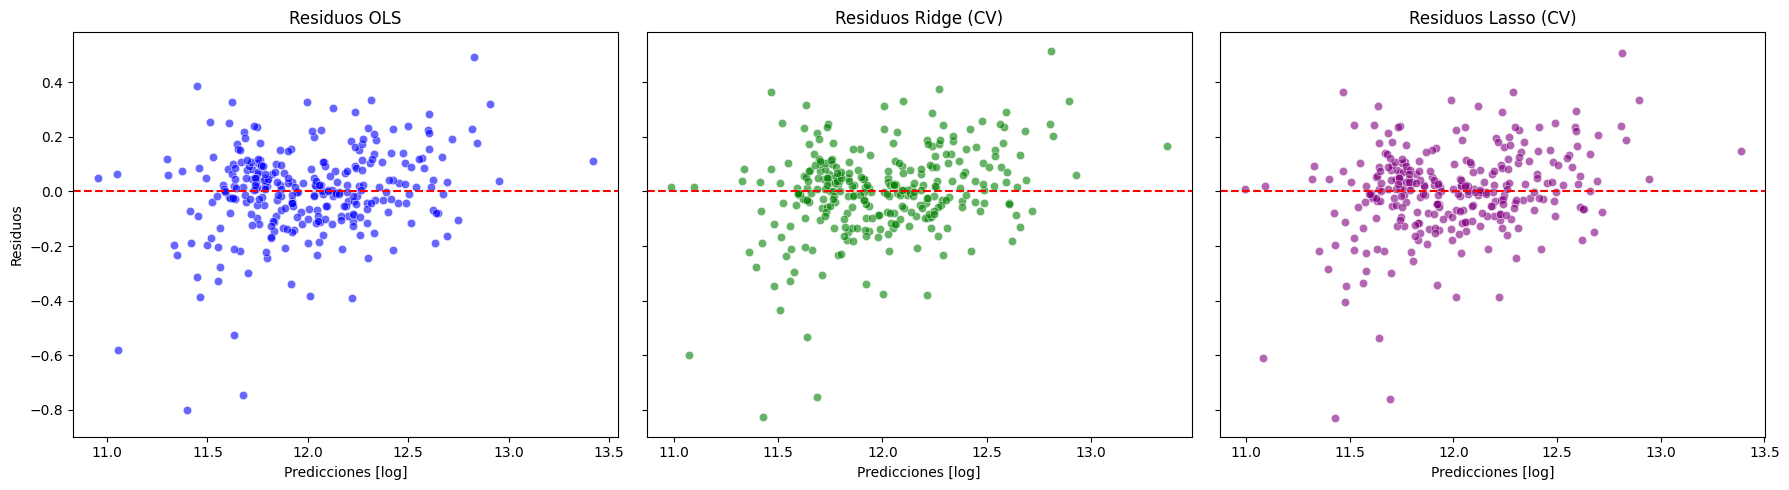

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los arrays de residuos (escala log)
residuos_ols = y_test - y_pred_ols
residuos_ridge = y_test - y_pred_ridge_cv
residuos_lasso = y_test - y_pred_lasso_cv

# 2. Armamos la grilla de gráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico para OLS
sns.scatterplot(x=y_pred_ols, y=residuos_ols, ax=axes[0], alpha=0.6, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--') # Línea de referencia en cero
axes[0].set_title('Residuos OLS')
axes[0].set_xlabel('Predicciones [log]')
axes[0].set_ylabel('Residuos')

# Gráfico para Ridge
sns.scatterplot(x=y_pred_ridge_cv, y=residuos_ridge, ax=axes[1], alpha=0.6, color='green')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuos Ridge (CV)')
axes[1].set_xlabel('Predicciones [log]')

# Gráfico para Lasso
sns.scatterplot(x=y_pred_lasso_cv, y=residuos_lasso, ax=axes[2], alpha=0.6, color='purple')
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title('Residuos Lasso (CV)')
axes[2].set_xlabel('Predicciones [log]')

plt.tight_layout()
plt.show()

Yo observo un patron (como una sonrisa suave) se me ocurre que podria ser una cuadrática corrida algo que aproxime mejor, a eso se refiere?


#Ejercicio 2
Cambiar la Métrica de CV: En `LassoCV` y `RidgeCV`, el scoring por defecto es el error cuadrático negativo. Investigá cómo podrías usar el "mean_absolute_error" en su lugar. ¿Cambia el `alpha` seleccionado?


In [ ]:
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

alphas = np.logspace(-4, 2, 100)

# --- RidgeCV ---
ridge_cv_sc = RidgeCV(alphas=alphas, store_cv_results=True, scoring=mae_scorer)
ridge_cv_sc.fit(X_train_scaled, y_train)

print("--- Búsqueda del mejor Alpha para Ridge ---")
print(f"Mejor alpha encontrado para Ridge: {ridge_cv.alpha_:.4f}")
print(f"Mejor alpha encontrado para Ridge MAE: {ridge_cv_sc.alpha_:.4f}")

# Evaluar el modelo Ridge final con el mejor alpha
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)
print(f"MSE de Ridge con CV: {mse_ridge_cv:.4f}")
print(f"R² de Ridge con CV: {r2_ridge_cv:.4f}")


param_grid = {'alpha': alphas}
# Configurar GridSearchCV con el modelo Lasso estándar
grid_lasso_cv = GridSearchCV(
    estimator=Lasso(random_state=42),
    param_grid=param_grid,
    scoring=mae_scorer,  # Aquí sí puedes cambiar el scoring
    cv=5
)

grid_lasso_cv.fit(X_train_scaled, y_train)
print("--- Búsqueda del mejor Alpha para Lasso ---")
print(f"Mejor alpha encontrado para Lasso: {lasso_cv.alpha_:.4f}")
print(f"Mejor alpha encontrado para Lasso MAE: {grid_lasso_cv.best_params_['alpha']:.4f}")

--- Búsqueda del mejor Alpha para Ridge ---
Mejor alpha encontrado para Ridge: 86.9749
Mejor alpha encontrado para Ridge MAE: 0.0001
MSE de Ridge con CV: 0.0254
R² de Ridge con CV: 0.8638
--- Búsqueda del mejor Alpha para Lasso ---
Mejor alpha encontrado para Lasso: 0.0057
Mejor alpha encontrado para Lasso MAE: 0.0007


Si, como vemos cambian los alphas de cada modelo.

#Ejercicio 3
Implementar K-Fold a Mano: En lugar de usar `RidgeCV`, instancia un `KFold(n_splits=5)`, iterá sobre los pliegues, entrená un modelo `Ridge` para un alpha fijo en cada pliegue y calculá el error promedio. Compará tu resultado con el de la clase `RidgeCV`.

In [ ]:

ridge_cv = RidgeCV(alphas=alphas, store_cv_results=False, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)


kf = KFold(n_splits=5, shuffle=True, random_state=42)


# --- LA SOLUCIÓN: Forzamos a que sean arrays puros de Numpy ---
X_puro = X_train_scaled.values if hasattr(X_train_scaled, 'columns') else X_train_scaled
y_puro = y_train.values

best_alpha = None
best_error = 1e10
print("--- Iniciando K-Fold a Mano ---")

for alpha in alphas:
  lista_mse = []
  # Entrenamos el modelo

  for i, (indices_train, indices_val) in enumerate(kf.split(X_puro)):

      # Ahora que son Numpy puros, la indexación directa por corchetes NO falla
      X_tr, X_val = X_puro[indices_train], X_puro[indices_val]
      y_tr, y_val = y_puro[indices_train], y_puro[indices_val]

      modelo_ridge = Ridge(alpha=alpha, random_state=42)
      modelo_ridge.fit(X_tr, y_tr)

      # Predecimos y evaluamos
      pred_val = modelo_ridge.predict(X_val)
      mse_vuelta = mean_squared_error(y_val, pred_val)
      lista_mse.append(mse_vuelta)

  mean = np.mean(lista_mse)
  if best_alpha == None or best_error > mean:
    best_error = mean
    best_alpha = alpha


modelo_final = Ridge(alpha=best_alpha)
modelo_final.fit(X_train_scaled, y_train)
mse_manual_test = mean_squared_error(y_test, modelo_final.predict(X_test_scaled))

print("\n--- Resultado Final ---")
print(f"Best error: {mse_manual_test:.6f}, alpha: {best_alpha}. RidgeCV MSE: {mse_ridge_cv}")

--- Iniciando K-Fold a Mano ---

--- Resultado Final ---
Best error: 0.025300, alpha: 75.64633275546291. RidgeCV MSE: 0.025425429208630546


Como podemos ver, en Ridge obtuvimos MSE de Ridge con CV: 0.02540, como vemos con el KFold manual nos dio 0.025300 y alpha optimo de 75.6463. Los resultados son casi iguales debido a que coinciden en el MSE esperado.


#Ejercicio 4
Características Polinómicas: Sospechamos que la relación entre `GrLivArea` y `SalePrice` no es perfectamente lineal. Usá `sklearn.preprocessing.PolynomialFeatures` para crear una característica `GrLivArea` al cuadrado y añadila al modelo. ¿Mejora el R²?

In [ ]:
# 1. Instanciamos el transformador polinomial de grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Generamos las características polinomiales (GrLivArea y GrLivArea^2)
grliv_train_poly = poly.fit_transform(X_train_scaled[['GrLivArea']])
grliv_test_poly = poly.fit_transform(X_test_scaled[['GrLivArea']])



# 3. Convertimos el resultado de Numpy a DataFrame de Pandas
grliv_poly_df = pd.DataFrame(
    grliv_train_poly,
    columns=['GrLivArea', 'GrLivArea_Sq'],
    index=X_train_scaled.index
)
grliv_poly_test_df = pd.DataFrame(
    grliv_test_poly,
    columns=['GrLivArea', 'GrLivArea_Sq'],
    index=X_test_scaled.index
)



# 4. Construimos los nuevos conjuntos de datos combinados
X_train_poly = X_train_scaled.drop(columns=['GrLivArea']).join(grliv_poly_df)
X_test_poly = X_test_scaled.drop(columns=['GrLivArea']).join(grliv_poly_test_df)

display(X_train_poly.head())

# 5. Volvemos a entrenar OLS con los datos polinomiales
ols_poly = LinearRegression()
ols_poly.fit(X_train_poly, y_train)
r2_ols_poly = ols_poly.score(X_test_poly, y_test)

# 6. Volvemos a optimizar Ridge con los nuevos datos
ridge_poly_cv = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_poly_cv.fit(X_train_poly, y_train)
r2_ridge_poly = ridge_poly_cv.score(X_test_poly, y_test)

# 7. Volvemos a optimizar Lasso con los nuevos datos
lasso_poly_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_poly_cv.fit(X_train_poly, y_train)
r2_lasso_poly = lasso_poly_cv.score(X_test_poly, y_test)


print("--- Comparativa de R² con Características Polinomiales ---")
print(f"Nuevo R² OLS:   {r2_ols_poly:.4f}  (Antes: 0.8375)")
print(f"Nuevo R² Ridge: {r2_ridge_poly:.4f} (Antes: 0.8340)")
print(f"Nuevo R² Lasso: {r2_lasso_poly:.4f} (Antes: 0.8366)")

,OverallQual,YearBuilt,TotalBsmtSF,FullBath,GarageCars,LotArea,OverallCond,BedroomAbvGr,GrLivArea,GrLivArea_Sq
0,-0.820445,-0.455469,0.572612,-1.055566,-1.056544,-0.212896,0.372217,0.136218,-0.407093,0.165725
1,-0.088934,0.718609,-0.596547,0.773664,0.295092,-0.265245,1.268609,0.136218,0.083170,0.006917
2,-0.820445,-1.988293,-0.603357,-1.055566,-2.408179,-0.177841,1.268609,-1.106774,-1.395250,1.946723
3,-0.820445,-1.107734,-0.750921,-1.055566,-1.056544,-0.324474,1.268609,0.136218,0.458975,0.210658
4,-0.820445,-1.531707,-0.081209,0.773664,-1.056544,-0.529035,0.372217,0.136218,0.312087,0.097398


--- Comparativa de R² con Características Polinomiales ---
Nuevo R² OLS:   0.8715  (Antes: 0.8375)
Nuevo R² Ridge: 0.8715 (Antes: 0.8340)
Nuevo R² Lasso: 0.8715 (Antes: 0.8366)


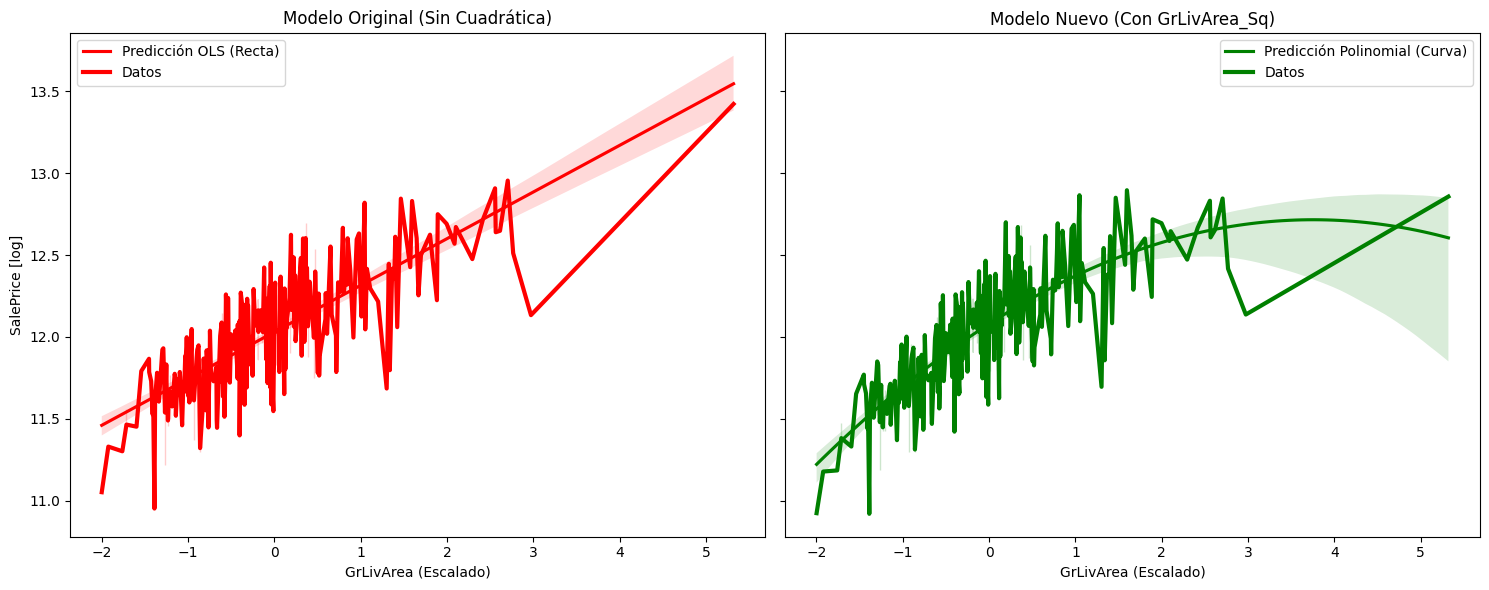

In [ ]:
# 1. Creamos un lienzo con 2 gráficos (el antes y el después)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- GRÁFICO 1: El Modelo Lineal Original (Antes) ---

#sns.scatterplot(x=X_test_scaled['GrLivArea'], y=y_test, ax=axes[0], alpha=0.5, color='blue')
# --- REEMPLAZO PARA EL GRÁFICO 1 (Izquierda) ---
# Cambiamos sns.lineplot por regplot. 'scatter=False' para que no duplique los puntos azules.
sns.regplot(x=X_test_scaled['GrLivArea'], y=y_pred_ols, ax=axes[0], scatter=False, color='red', label='Predicción OLS (Recta)')

# Dibujamos la recta usando una línea de regresión simple sobre las predicciones viejas
sns.lineplot(x=X_test_scaled['GrLivArea'], y=y_pred_ols, ax=axes[0], color='red', linewidth=3, label='Datos')
axes[0].set_title('Modelo Original (Sin Cuadrática)')
axes[0].set_xlabel('GrLivArea (Escalado)')
axes[0].set_ylabel('SalePrice [log]')



# --- GRÁFICO 2: El Modelo Polinomial (Después) ---
#sns.scatterplot(x=X_test_scaled['GrLivArea'], y=y_test, ax=axes[1], alpha=0.5, color='blue')

# --- REEMPLAZO PARA EL GRÁFICO 2 (Derecha) ---
# Para la curva, usamos regplot pero le avisamos que busque una tendencia de segundo grado (order=2)
sns.regplot(x=X_test_scaled['GrLivArea'], y=ols_poly.predict(X_test_poly), ax=axes[1], scatter=False, order=2, color='green', label='Predicción Polinomial (Curva)')

# Al ordenar los valores de X, Matplotlib puede dibujar la curva suave de las nuevas predicciones
orden_index = X_test_scaled['GrLivArea'].argsort()
sns.lineplot(
    x=X_test_scaled['GrLivArea'].iloc[orden_index],
    y=ols_poly.predict(X_test_poly).iloc[orden_index] if hasattr(ols_poly.predict(X_test_poly), 'iloc') else ols_poly.predict(X_test_poly)[orden_index],
    ax=axes[1], color='green', linewidth=3, label='Datos'
)
axes[1].set_title('Modelo Nuevo (Con GrLivArea_Sq)')
axes[1].set_xlabel('GrLivArea (Escalado)')

plt.tight_layout()
plt.show()

#Ejercicio 5
Impacto de Outliers: Encontrá la casa más cara en el `df_subset`. Eliminala y volvé a entrenar el modelo OLS (con el target logarítmico). ¿Cómo cambian los coeficientes y el R²?


In [ ]:
# 1. Encontramos el índice de la fila con el precio más alto
indice_mas_caro = df['SalePrice'].idxmax()

# (Opcional) Chusmeamos los datos de esa casa antes de borrarla
print(f"Eliminando la casa con índice {indice_mas_caro}. Precio: {df.loc[indice_mas_caro, 'SalePrice']}")

# 2. Borramos esa fila del DataFrame original
df_limpio_0 = df.drop(index=indice_mas_caro)

# Como observamos que hay 2 outliers en el dataset, una segunda casa valuada en 745000 la vamos a eliminar también
indice_mas_caro_2 = df_limpio_0['SalePrice'].idxmax()
print(f"Eliminando la casa con índice {indice_mas_caro_2}. Precio: {df_limpio_0.loc[indice_mas_caro_2, 'SalePrice']}")

df_limpio = df_limpio_0.drop(index=indice_mas_caro_2)

Eliminando la casa con índice 691. Precio: 755000
Eliminando la casa con índice 1182. Precio: 745000


In [ ]:
# Creamos un DataFrame más pequeño y manejamos valores faltantes de forma simple
df_subset_limpio = df_limpio[numeric_features_plus + [target_variable]].dropna()

print(f"\nDimensiones del subconjunto de datos: {df_subset.shape}")
print("\nDescripción estadística del subconjunto:")
print(df_subset_limpio.describe())


Dimensiones del subconjunto de datos: (1460, 7)

Descripción estadística del subconjunto:
         GrLivArea  OverallQual    YearBuilt  TotalBsmtSF     FullBath  \
count  1458.000000  1458.000000  1458.000000  1458.000000  1458.000000   
mean   1511.512346     6.093964  1971.235254  1055.560357     1.563100   
std     514.873223     1.376369    30.210793   436.089145     0.548721   
min     334.000000     1.000000  1872.000000     0.000000     0.000000   
25%    1128.500000     5.000000  1954.000000   795.250000     1.000000   
50%    1461.500000     6.000000  1972.500000   991.000000     2.000000   
75%    1776.000000     7.000000  2000.000000  1296.750000     2.000000   
max    5642.000000    10.000000  2010.000000  6110.000000     3.000000   

        GarageCars        LotArea  OverallCond  BedroomAbvGr      SalePrice  
count  1458.000000    1458.000000  1458.000000   1458.000000    1458.000000  
mean      1.765432   10505.768861     5.575446      2.864883  180140.566529  
std     

In [ ]:
# 1. Definir características (X) y objetivo (y)
X_limpio = df_subset_limpio[numeric_features_plus]
y_raw_limpio = df_subset_limpio[target_variable] # Guardamos el 'y' original para evaluación final

# !! CAMBIO CLAVE !!
# Aplicamos la transformación logarítmica a la variable objetivo 'y'
# Esto estabiliza la varianza y normaliza la escala del problema.
y_limpio = np.log1p(y_raw_limpio)

# 2. Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train_limpio, X_test_limpio, y_train_limpio, y_test_limpio = train_test_split(X_limpio, y_limpio, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento limpio: {X_train_limpio.shape}")
print(f"Tamaño del set de prueba limpio: {X_test_limpio.shape}")

# 3. Escalar las características numéricas
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar fuga de datos (data leakage)
X_train_scaled_limpio = scaler.fit_transform(X_train_limpio)  #NORMALIZA, RESTA LA MEDIA Y DIVIDE POR LA DISPERSION
# Aplicamos la misma transformación a los datos de prueba
X_test_scaled_limpio = scaler.transform(X_test_limpio)

# Convertimos los arrays de numpy de vuelta a DataFrames de pandas para mejor legibilidad
X_train_scaled_limpio = pd.DataFrame(X_train_scaled_limpio, columns=numeric_features_plus)
X_test_scaled_limpio = pd.DataFrame(X_test_scaled_limpio, columns=numeric_features_plus)

Tamaño del set de entrenamiento limpio: (1166, 9)
Tamaño del set de prueba limpio: (292, 9)


In [ ]:
# Crear y entrenar el modelo de Regresión Lineal
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Crear y entrenar el modelo de Regresión Lineal para el dataset sin outliers
ols_model_limpio = LinearRegression()
ols_model_limpio.fit(X_train_scaled_limpio, y_train_limpio)

# Realizar predicciones en el conjunto de prueba (las predicciones estarán en escala logarítmica)
y_pred_ols = ols_model.predict(X_test_scaled)


# Realizar predicciones en el conjunto de prueba sin outliers (las predicciones estarán en escala logarítmica)
y_pred_ols_limpio = ols_model_limpio.predict(X_test_scaled_limpio)

#print(f"Tamaño del set de entrenamiento: {X_train.shape}")
#print(f"Tamaño del set de prueba: {X_test.shape}")

# Evaluar el modelo
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)


# Evaluar el modelo sin outliers
mse_ols_limpio = mean_squared_error(y_test_limpio, y_pred_ols_limpio)
r2_ols_limpio = r2_score(y_test_limpio, y_pred_ols_limpio)

print("--- Evaluación del Modelo de Regresión Lineal (OLS) ---")
resumen_ols = {"OLS Completo":[mse_ols, r2_ols]}
evaluacion_df = pd.DataFrame(resumen_ols ,index=["MSE(log)","R2"])
evaluacion_df["Sin Outliers"] = [mse_ols_limpio, r2_ols_limpio]
print(evaluacion_df)



# Ver los coeficientes del modelo
coef_df = pd.DataFrame(ols_model.coef_, index=numeric_features_plus, columns=['Coeficiente_OLS'])
# Añadir los coeficientes finales al DataFrame
coef_df['Coef_OLS_SinOutliers'] = ols_model_limpio.coef_
print("\nCoeficientes del modelo OLS con y sin Outliers:")
print(coef_df)

# Ver el Intercept y el precio base promedio
print("\nInterceptos y precios base del modelo OLS con y sin Outliers:")
intercept_completo = {"OLS Completo":[ols_model.intercept_,np.expm1(ols_model.intercept_)]}
intercept_df = pd.DataFrame(intercept_completo, index = ["Ordenada al origen (Intercept)","Precio base promedio en USD"])
intercept_df["OLS Sin Outliers"] = [ols_model_limpio.intercept_,np.expm1(ols_model_limpio.intercept_)]
print(intercept_df)


--- Evaluación del Modelo de Regresión Lineal (OLS) ---
          OLS Completo  Sin Outliers
MSE(log)      0.024630      0.020952
R2            0.868012      0.873573

Coeficientes del modelo OLS con y sin Outliers:
              Coeficiente_OLS  Coef_OLS_SinOutliers
GrLivArea            0.124393              0.123504
OverallQual          0.123754              0.124979
YearBuilt            0.108563              0.104389
TotalBsmtSF          0.042973              0.046207
FullBath            -0.003818             -0.001769
GarageCars           0.068857              0.069145
LotArea              0.031874              0.030132
OverallCond          0.065631              0.064737
BedroomAbvGr         0.001039             -0.001788

Interceptos y precios base del modelo OLS con y sin Outliers:
                                 OLS Completo  OLS Sin Outliers
Ordenada al origen (Intercept)      12.030658         12.022723
Precio base promedio en USD     167820.855352     166494.391196


Vemos que los valores de MSE y R2 mejoran al eliminar los outliers

#Ejercicio 6
*Comparar MAE vs MSE*: Calculá el `mean_absolute_error` (MAE) para todos los modelos finales (OLS, RidgeCV, LassoCV) en la escala logarítmica. ¿Por qué el MAE es menor que el MSE?


In [ ]:
alphas = np.logspace(-4, 2, 100)


# --- OLS ---
# Crear y entrenar el modelo de Regresión Lineal
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
y_pred_ols = ols_model.predict(X_test_scaled)

mse_ols = mean_squared_error(y_test, y_pred_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

print("--- Evaluación del Modelo de Regresión Lineal (OLS) ---")
print(f"MSE para OLS: {mse_ols:.4f}")
print(f"MAE para OLS: {mae_ols:.4f}")

print('')

# --- RidgeCV ---
ridge_cv_sc = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv_sc.fit(X_train_scaled, y_train)

# Evaluar el modelo Ridge final con el mejor alpha
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)
mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
print(f"MSE de Ridge con CV: {mse_ridge_cv:.4f}")
print(f"MAE de Ridge con CV: {mae_ridge_cv:.4f}")

print('')



# --- LassoCV ---
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

# Evaluar el modelo Lasso final
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)
mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
mae_ols = mean_absolute_error(y_test, y_pred_lasso_cv)
print(f"MSE de Lasso con CV: {mse_lasso_cv:.4f}")
print(f"MAE de Lasso con CV: {mae_ols:.4f}")


--- Evaluación del Modelo de Regresión Lineal (OLS) ---
MSE para OLS: 0.0246
MAE para OLS: 0.1110

MSE de Ridge con CV: 0.0254
MAE de Ridge con CV: 0.1114

MSE de Lasso con CV: 0.0255
MAE de Lasso con CV: 0.1118


El MSE suele ser mayor que el MAE porque eleva al cuadrado cada error, por lo que todos los errores son positivos y los errores grandes reciben una penalización mucho mayor.Cuando los errores son menores que 1 (algo habitual si la variable respuesta está en escala logarítmica), su cuadrado es menor que el valor absoluto. Sin embargo, unos pocos errores superiores a 1 aumentan mucho el promedio del MSE.

# Ejercicio 7

**Importancia de Características**: Ordená los coeficientes del modelo `RidgeCV` final de mayor a menor en valor absoluto. ¿Cuáles son los 3 features más influyentes según este modelo?


In [ ]:
# Ver los coeficientes del modelo
coef_df = pd.DataFrame(ridge_cv.coef_, index=numeric_features_plus, columns=['Coeficientes RidgeCV'])
print("\nCoeficientes del modelo OLS:")
print(coef_df.sort_values(by='Coeficientes RidgeCV', ascending=False))


Coeficientes del modelo OLS:
              Coeficientes RidgeCV
OverallQual               0.120712
GrLivArea                 0.107744
YearBuilt                 0.094366
GarageCars                0.070850
OverallCond               0.058040
TotalBsmtSF               0.047918
LotArea                   0.031067
FullBath                  0.009310
BedroomAbvGr              0.003581


Las 3 features mas influyentes para SalesPrice, de acuerdo al resultado anterior, son: OverallQual, GrLivArea, YearBuilt.

# Ejercicio 8
Efecto del Alpha en Lasso: Creá un gráfico que muestre cómo cambian los coeficientes de Lasso a medida que `alpha` aumenta. Podés usar la información almacenada en `lasso_cv.path_`.

In [ ]:
# Calculamos el regularization path de Lasso sobre un rango amplio de alphas
alphas_path, coefs_path, _ = lasso_cv.path(X_train_scaled, y_train, alphas=np.logspace(-4, 0, 200))

# coefs_path tiene forma (n_features, n_alphas): un coeficiente por feature por alpha
fig = go.Figure()
for i, feature in enumerate(numeric_features_plus):
    fig.add_trace(go.Scatter(
        x=alphas_path,
        y=coefs_path[i],
        mode='lines',
        name=feature
    ))

# Marcamos con linea vertical el alpha optimo que encontro LassoCV
fig.add_vline(
    x=lasso_cv.alpha_,
    line_dash="dash",
    line_color="black",
    annotation_text="alpha optimo = " + str(round(lasso_cv.alpha_, 4)),
    annotation_position="top right"
)

fig.update_layout(
    title='Efecto del Alpha en los Coeficientes de Lasso (Regularization Path)',
    xaxis_title='Alpha',
    xaxis_type='log',
    yaxis_title='Valor del Coeficiente',
    legend_title='Feature'
)
fig.show()

El gráfico muestra cómo cada coeficiente se va hacia cero a medida que alpha aumenta.
La línea vertical indica el alpha óptimo encontrado por LassoCV con validación cruzada.

**Observaciones clave:**
- **FullBath** y **BedroomAbvGr** son los primeros en zerificarse: Lasso los descarta como poco informativos.
- **OverallQual** y **GrLivArea** son los últimos en llegar a cero: son las variables más robustas del modelo.
- El alpha óptimo cae en la zona donde se eliminaron los features ruidosos pero aún se conservan los relevantes.

# Ejercicio 9
Regresión Lineal Simple vs. Múltiple: Entrená un modelo de regresión lineal simple para cada una de las características en `numeric_features` por separado. Compará el coeficiente de cada característica en su modelo simple con su coeficiente en el modelo múltiple (OLS). ¿Por qué son diferentes?

In [ ]:
# Usamos las 6 features originales (numeric_features) para comparar directamente
# con el modelo OLS multiple de la seccion 3 del taller
X_simple = df_subset[numeric_features]
y_simple = np.log1p(df_subset[target_variable])

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

scaler_s = StandardScaler()
X_train_s_sc = pd.DataFrame(scaler_s.fit_transform(X_train_s), columns=numeric_features)
X_test_s_sc  = pd.DataFrame(scaler_s.transform(X_test_s),  columns=numeric_features)

# Modelo OLS multiple (todas las features juntas)
ols_multi = LinearRegression()
ols_multi.fit(X_train_s_sc, y_train_s)

# Un modelo OLS simple por cada feature
simple_coefs = {}
for feature in numeric_features:
    m = LinearRegression()
    m.fit(X_train_s_sc[[feature]], y_train_s)
    simple_coefs[feature] = m.coef_[0]

# Tabla comparativa
comparison_df = pd.DataFrame({
    'Regresion_Simple': simple_coefs,
    'Regresion_Multiple': dict(zip(numeric_features, ols_multi.coef_))
})
comparison_df['Diferencia'] = (
    comparison_df['Regresion_Simple'] - comparison_df['Regresion_Multiple']
).round(4)

print("--- Comparacion de Coeficientes: Simple vs Multiple ---")
print(comparison_df.round(4))

# Grafico de barras comparativo
fig = go.Figure([
    go.Bar(name='Simple',   x=numeric_features, y=comparison_df['Regresion_Simple']),
    go.Bar(name='Multiple', x=numeric_features, y=comparison_df['Regresion_Multiple'])
])
fig.update_layout(
    title='Coeficientes: Regresion Simple vs Multiple por Feature',
    barmode='group',
    xaxis_title='Feature',
    yaxis_title='Valor del Coeficiente'
)
fig.show()

--- Comparacion de Coeficientes: Simple vs Multiple ---
             Regresion_Simple  Regresion_Multiple  Diferencia
GrLivArea              0.2690              0.1266      0.1424
OverallQual            0.3155              0.1384      0.1770
YearBuilt              0.2252              0.0744      0.1508
TotalBsmtSF            0.2332              0.0445      0.1886
FullBath               0.2279             -0.0069      0.2348
GarageCars             0.2672              0.0715      0.1957


**Por que son diferentes los coeficientes?**

En el modelo simple, cada feature absorbe tambien el efecto de las variables correlacionadas que no estan presentes. En el modelo multiple, los coeficientes reflejan el efecto **marginal puro** de cada variable, manteniendo las demas constantes.

**Ejemplos concretos:**
- **GarageCars** tiene un coeficiente mas alto en el modelo simple porque las casas con mas garage tambien suelen tener mayor area (GrLivArea) y mejor calidad (OverallQual). Al incluir todas esas variables juntas, su efecto individual se reduce.
- **FullBath** puede cambiar de signo entre modelos porque esta correlacionado con el tamanio de la casa. Sin controlar por GrLivArea parece que agrega valor; controlando por ella puede resultar redundante.
- Este fenomeno se llama **multicolinealidad** y es la razon principal por la que la regresion multiple es mas informativa que N regresiones simples.

#Ejercicio 10
**Modelo para Producción:** Si tuvieras que elegir uno de los modelos entrenados para ponerlo en producción y predecir precios de casas para un cliente, ¿cuál elegirías y por qué? Justificá tu respuesta basándote en el rendimiento (R², MSE), la interpretabilidad (coeficientes) y la simplicidad del modelo.

Como podemos observar en la siguiente imagen, si nos basamos solo en los valores del rendimiento veríamos que los resultados fueron muy parejos, tanto el error cuadrático medio como el coeficiente de Determinación, es aquí donde debemos decidir pensando en las capacidades de los modelos, OLS es más frágil ante la entrada de nuevos datos que pudieran ser outliers, en ese caso podría tirar una predicción un poco delirante. En ese caso tanto Ridge como Lasso mantiene vivas todas la variables comprimiendo los coeficientes, y es aquí donde nos parece que **Lasso** termina siendo el modelo "ganador" por la simplificación que hace al eliminar coeficientes de características intrascendentes.(Ver que les aplica el valor 0 a las características **FullBath** y **BedroomAbvGr**)

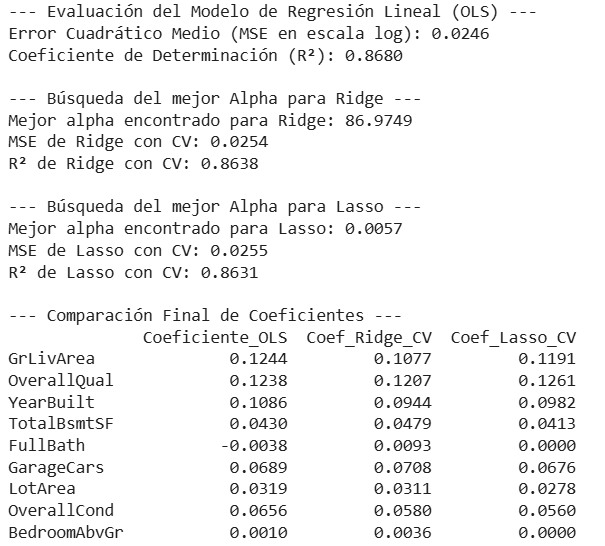